In [1]:
# !pip install tensorflow pandas numpy scikit-learn gensim datasets transformers seqeval


In [ ]:
# pip install keras==2.13.1
# pip install transformers==4.51.3
# pip install tensorflow==2.13

In [2]:
# Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. 
#     For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`

In [3]:
# 🧪 STEP 1: Data Loading and Preprocessing



In [4]:
# 📌 STEP 1: Load and Sample 10% of the Dataset (Use 100% Later)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


In [7]:

# Load dataset
df = pd.read_csv("ner_dataset.csv", encoding="latin1")
df = df.ffill()
df = df[["Sentence #", "Word", "Tag"]]

# ✅ USE 10% DATA FOR QUICK TESTING
sampled_sentences = df["Sentence #"].dropna().unique()
# sample_size = int(0.05 * len(sampled_sentences))  # 🔁 CHANGE TO 1.0 * ... TO USE 100% LATER

sample_size = int(1.0 * len(sampled_sentences))  # 🔁 CHANGE TO 1.0 * ... TO USE 100% LATER

sampled_sentences = np.random.choice(sampled_sentences, sample_size, replace=False)
df = df[df["Sentence #"].isin(sampled_sentences)]

# 📍 TO SWITCH TO 100% DATA LATER, COMMENT ABOVE 4 LINES

# Sentence grouping
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #")[["Word", "Tag"]].apply(
            lambda s: list(zip(s["Word"].values, s["Tag"].values))
        )
        self.sentences = [s for s in self.grouped]

getter = SentenceGetter(df)
sentences = getter.sentences

# Create mappings
words = list(set(df["Word"].values))
words.append("ENDPAD")
tags = list(set(df["Tag"].values))

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: w for w, i in tag2idx.items()}

max_len = 75
embedding_dim = 300

X = [[word2idx.get(w[0], 0) for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=word2idx["ENDPAD"])
y = [[tag2idx[w[1]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])
y = [to_categorical(i, num_classes=len(tags)) for i in y]

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)


In [8]:
# 📌 STEP 2: Define BiLSTM Model Builder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Bidirectional

def build_bilstm_model(embedding_matrix=None, trainable=False):
    input = Input(shape=(max_len,))
    if embedding_matrix is not None:
        model = Embedding(input_dim=len(word2idx)+1, output_dim=embedding_dim,
                          weights=[embedding_matrix], input_length=max_len,
                          trainable=trainable)(input)
    else:
        model = Embedding(input_dim=len(word2idx)+1, output_dim=embedding_dim,
                          input_length=max_len)(input)
    model = Bidirectional(LSTM(units=50, return_sequences=True, recurrent_dropout=0.1))(model)
    out = TimeDistributed(Dense(len(tags), activation="softmax"))(model)
    model = Model(input, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [9]:
# 📌 STEP 3: Train Baseline BiLSTM (Random Embeddings)
baseline_model = build_bilstm_model()

baseline_history = baseline_model.fit(np.array(X_train), np.array(y_train),validation_data=(np.array(X_val), np.array(y_val)),
                   batch_size=32, epochs=5, verbose=1)


Epoch 1/5
1050/1050 [==============================] - 373s 350ms/step - loss: 0.1138 - accuracy: 0.9765 - val_loss: 0.0397 - val_accuracy: 0.9885
Epoch 2/5
1050/1050 [==============================] - 264s 251ms/step - loss: 0.0307 - accuracy: 0.9909 - val_loss: 0.0317 - val_accuracy: 0.9904
Epoch 3/5
1050/1050 [==============================] - 275s 262ms/step - loss: 0.0216 - accuracy: 0.9933 - val_loss: 0.0301 - val_accuracy: 0.9908
Epoch 4/5
1050/1050 [==============================] - 250s 238ms/step - loss: 0.0169 - accuracy: 0.9946 - val_loss: 0.0313 - val_accuracy: 0.9908
Epoch 5/5
1050/1050 [==============================] - 284s 270ms/step - loss: 0.0135 - accuracy: 0.9956 - val_loss: 0.0329 - val_accuracy: 0.9904


In [10]:
baseline_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 75)]              0         
                                                                 
 embedding_1 (Embedding)     (None, 75, 300)           10553700  
                                                                 
 bidirectional_1 (Bidirecti  (None, 75, 100)           140400    
 onal)                                                           
                                                                 
 time_distributed_1 (TimeDi  (None, 75, 17)            1717      
 stributed)                                                      
                                                                 
Total params: 10695817 (40.80 MB)
Trainable params: 10695817 (40.80 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
i = np.random.randint(0, x_test.shape[0])
p = baseline_model.predict(np.array([x_test[i]]))
p = np.argmax(p, axis=-1)

y_true = np.argmax(np.array(y_test), axis=-1)[i]
print("{:15}{:5}\t {}\n".format("Word","True","Pred"))
print("-"*30)
for w,true,pred in zip(x_test[i], y_true, p[0]):
  print("{:15}{:5}\t{}".format(words[w-1], tags[true],tags[pred]))

In [13]:
# 📌 STEP 4: Train BiLSTM with Word2Vec Embeddings
import gensim.downloader as api
w2v_model = api.load("word2vec-google-news-300")

embedding_matrix = np.zeros((len(word2idx) + 1, embedding_dim))
for word, i in word2idx.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))




[==================================================] 100.0% 1662.8/1662.8MB downloaded
Epoch 1/3
53/53 [==============================] - 10s 110ms/step - loss: 0.4583 - accuracy: 0.9240 - val_loss: 0.2337 - val_accuracy: 0.9522
Epoch 2/3
53/53 [==============================] - 6s 104ms/step - loss: 0.2094 - accuracy: 0.9545 - val_loss: 0.2055 - val_accuracy: 0.9522
Epoch 3/3
53/53 [==============================] - 5s 102ms/step - loss: 0.1855 - accuracy: 0.9546 - val_loss: 0.1817 - val_accuracy: 0.9524


In [26]:
w2v_model_bilstm = build_bilstm_model(embedding_matrix=embedding_matrix, trainable=False)

w2v_history = w2v_model_bilstm.fit(np.array(X_train), np.array(y_train),validation_data=(np.array(X_val), np.array(y_val)),
                     batch_size=32, epochs=2, verbose=1)

Epoch 1/2
53/53 [==============================] - 12s 130ms/step - loss: 0.4740 - accuracy: 0.9242 - val_loss: 0.2399 - val_accuracy: 0.9522
Epoch 2/2
53/53 [==============================] - 7s 124ms/step - loss: 0.2177 - accuracy: 0.9545 - val_loss: 0.2169 - val_accuracy: 0.9522


In [9]:
# import torch
# print(torch.__version__)
# print(torch.cuda.is_available())  # True if CUDA GPU detected, else False


2.7.0+cu118
False


In [11]:
# 📌 STEP 5: Train BERT Model using Hugging Face
# ✅ Full Updated Code Using base_model (with DistilBERT)


from transformers import DistilBertTokenizerFast, TFDistilBertForTokenClassification
from transformers import DataCollatorForTokenClassification
from datasets import Dataset
import tensorflow as tf

# Tokenizer and model
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-cased")
base_model = TFDistilBertForTokenClassification.from_pretrained("distilbert-base-cased", num_labels=len(tags))

# Prepare data
token_sentences = [[w[0] for w in s] for s in sentences]
ner_tags = [[tag2idx[w[1]] for w in s] for s in sentences]

dataset = Dataset.from_dict({"tokens": token_sentences, "ner_tags": ner_tags})

# Tokenization & alignment
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(example["tokens"], truncation=True, is_split_into_words=True,
                                 padding="max_length", max_length=max_len)
    labels = []
    for i, label in enumerate(example["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_id])
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply tokenizer
encoded_dataset = dataset.map(tokenize_and_align_labels, batched=True)
encoded_dataset = encoded_dataset.train_test_split(test_size=0.2)

# Data collator
# data_collator = DataCollatorForTokenClassification(tokenizer)
data_collator = DataCollatorForTokenClassification(tokenizer, return_tensors="tf")


# Convert to tf.data.Dataset


bert_train = encoded_dataset["train"].to_tf_dataset(
    columns=["attention_mask", "input_ids", "labels"],  # Include labels here
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator,
)

bert_val = encoded_dataset["test"].to_tf_dataset(
    columns=["attention_mask", "input_ids", "labels"],  # Include labels here
    shuffle=False,
    batch_size=8,
    collate_fn=data_collator,
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForTokenClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForTokenClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForTokenClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForTokenClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able t

Map:   0%|          | 0/2397 [00:00<?, ? examples/s]

Epoch 1/2
240/240 [==============================] - 530s 2s/step - loss: 1.0127 - val_loss: 0.9232
Epoch 2/2
240/240 [==============================] - 513s 2s/step - loss: 0.9292 - val_loss: 0.9277


In [28]:
# Compile and train
# base_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), loss=base_model.compute_loss)
base_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3))

bert_history = base_model.fit(bert_train, validation_data=bert_val, epochs=2)

Epoch 1/2
240/240 [==============================] - 1183s 5s/step - loss: 0.9304 - val_loss: 0.9421
Epoch 2/2
240/240 [==============================] - 1662s 7s/step - loss: 0.9216 - val_loss: 0.9151


In [24]:
# 📌 STEP 6: Evaluate BiLSTM Models Using seqeval
from seqeval.metrics import classification_report

def predict_BiLSTM_Word2Vectags(model, X_data, y_data):
    pred = model.predict(X_data)
    pred_labels = np.argmax(pred, axis=-1)
    true_labels = np.argmax(y_data, axis=-1)

    pred_tag = [[idx2tag[i] for i in row] for row in pred_labels]
    true_tag = [[idx2tag[i] for i in row] for row in true_labels]
    
    # Optionally strip padding (e.g., "ENDPAD") for cleaner results
    cleaned_true_tag = []
    cleaned_pred_tag = []
    for t_seq, p_seq, x_seq in zip(true_tag, pred_tag, X_data):
        temp_t = []
        temp_p = []
        for t, p, x in zip(t_seq, p_seq, x_seq):
            if x != word2idx["ENDPAD"]:  # skip padded tokens
                temp_t.append(t)
                temp_p.append(p)
        cleaned_true_tag.append(temp_t)
        cleaned_pred_tag.append(temp_p)

    return cleaned_true_tag, cleaned_pred_tag


true_b, pred_b = predict_BiLSTM_Word2Vectags(baseline_model, X_test, y_test)
true_w, pred_w = predict_BiLSTM_Word2Vectags(w2v_model_bilstm, X_test, y_test)

print("📊 Baseline BiLSTM Performance:")
print(classification_report(true_b, pred_b))

print("\n📊 Word2Vec BiLSTM Performance:")
print(classification_report(true_w, pred_w))



15/15 [==============================] - 0s 27ms/step
📊 Baseline BiLSTM Performance:
              precision    recall  f1-score   support

         art       0.00      0.00      0.00        14
         eve       0.00      0.00      0.00         4
         geo       0.28      0.25      0.26       362
         gpe       0.00      0.00      0.00       141
         org       0.00      0.00      0.00       170
         per       0.00      0.00      0.00       160
         tim       0.00      0.00      0.00       208

   micro avg       0.28      0.08      0.13      1059
   macro avg       0.04      0.04      0.04      1059
weighted avg       0.09      0.08      0.09      1059


📊 Word2Vec BiLSTM Performance:
              precision    recall  f1-score   support

         art       0.00      0.00      0.00        14
         eve       0.00      0.00      0.00         4
         geo       0.45      0.02      0.05       362
         gpe       0.00      0.00      0.00       141
         org   

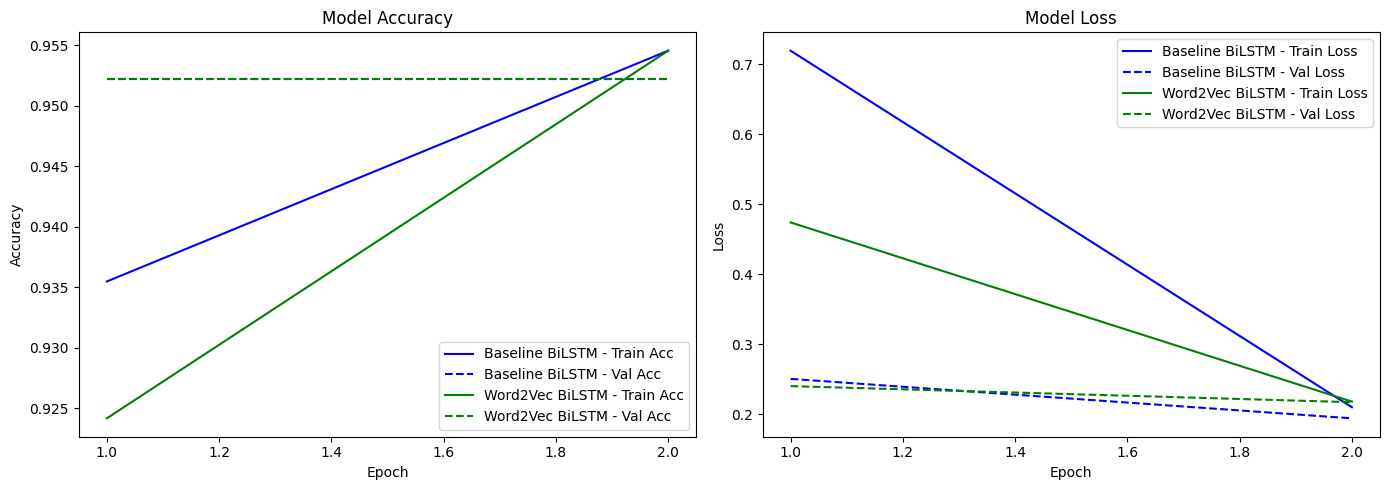

In [27]:
import matplotlib.pyplot as plt

def plot_model_comparison(history1, history2, label1="Baseline BiLSTM", label2="Word2Vec BiLSTM"):
    epochs = range(1, len(history1.history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history1.history['accuracy'], 'b-', label=f'{label1} - Train Acc')
    plt.plot(epochs, history1.history['val_accuracy'], 'b--', label=f'{label1} - Val Acc')
    plt.plot(epochs, history2.history['accuracy'], 'g-', label=f'{label2} - Train Acc')
    plt.plot(epochs, history2.history['val_accuracy'], 'g--', label=f'{label2} - Val Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history1.history['loss'], 'b-', label=f'{label1} - Train Loss')
    plt.plot(epochs, history1.history['val_loss'], 'b--', label=f'{label1} - Val Loss')
    plt.plot(epochs, history2.history['loss'], 'g-', label=f'{label2} - Train Loss')
    plt.plot(epochs, history2.history['val_loss'], 'g--', label=f'{label2} - Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_model_comparison(baseline_history, w2v_history)


In [23]:
import numpy as np
# from sklearn.metrics import classification_report
from seqeval.metrics import classification_report


def predict_tags(model, tf_dataset):
    pred_logits = model.predict(tf_dataset).logits  # <-- Extract logits
    pred_labels = np.argmax(pred_logits, axis=-1)

    all_true_labels = []
    for batch in tf_dataset:
        all_true_labels.extend(batch['labels'].numpy())

    true_labels = np.array(all_true_labels)

    pred_tags = [[idx2tag[idx] for idx in row] for row in pred_labels]
    true_tags = [[idx2tag[idx] if idx != -100 else 'O' for idx in row] for row in true_labels]

    return true_tags, pred_tags

# true_bert, pred_bert = predict_tags(base_model, X_test, y_test)
true_bert, pred_bert = predict_tags(base_model, bert_val)


print("\n📊 Transformer BERT Performance:")
print(classification_report(true_bert, pred_bert))


60/60 [==============================] - 32s 536ms/step

📊 Transformer BERT Performance:


/home/a/anaconda3/envs/new_eda/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/a/anaconda3/envs/new_eda/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         art       0.00      0.00      0.00        15
         eve       0.00      0.00      0.00         3
         geo       0.00      0.00      0.00       563
         gpe       0.00      0.00      0.00       174
         nat       0.00      0.00      0.00         3
         org       0.00      0.00      0.00       346
         per       0.00      0.00      0.00       291
         tim       0.00      0.00      0.00       228

   micro avg       0.00      0.00      0.00      1623
   macro avg       0.00      0.00      0.00      1623
weighted avg       0.00      0.00      0.00      1623



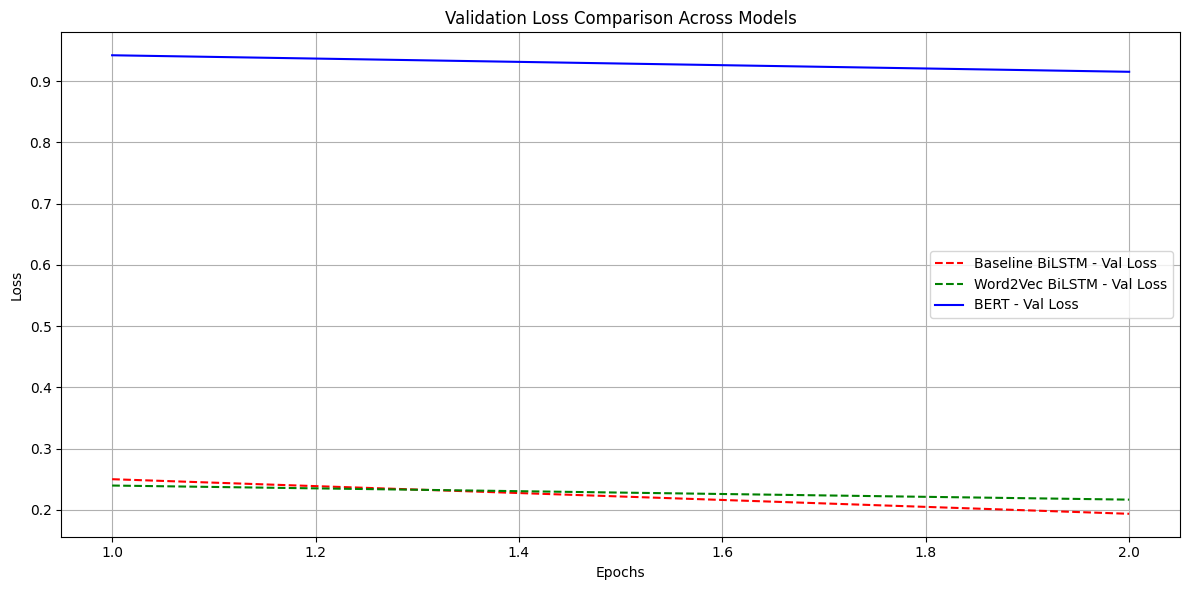

In [29]:
def plot_all_model_losses(baseline_hist, w2v_hist, bert_hist):
    epochs_bi = range(1, len(baseline_hist.history['loss']) + 1)
    epochs_bert = range(1, len(bert_hist.history['loss']) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(epochs_bi, baseline_hist.history['val_loss'], 'r--', label='Baseline BiLSTM - Val Loss')
    plt.plot(epochs_bi, w2v_hist.history['val_loss'], 'g--', label='Word2Vec BiLSTM - Val Loss')
    plt.plot(epochs_bert, bert_hist.history['val_loss'], 'b-', label='BERT - Val Loss')

    plt.title("Validation Loss Comparison Across Models")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call it
plot_all_model_losses(baseline_history, w2v_history, bert_history)


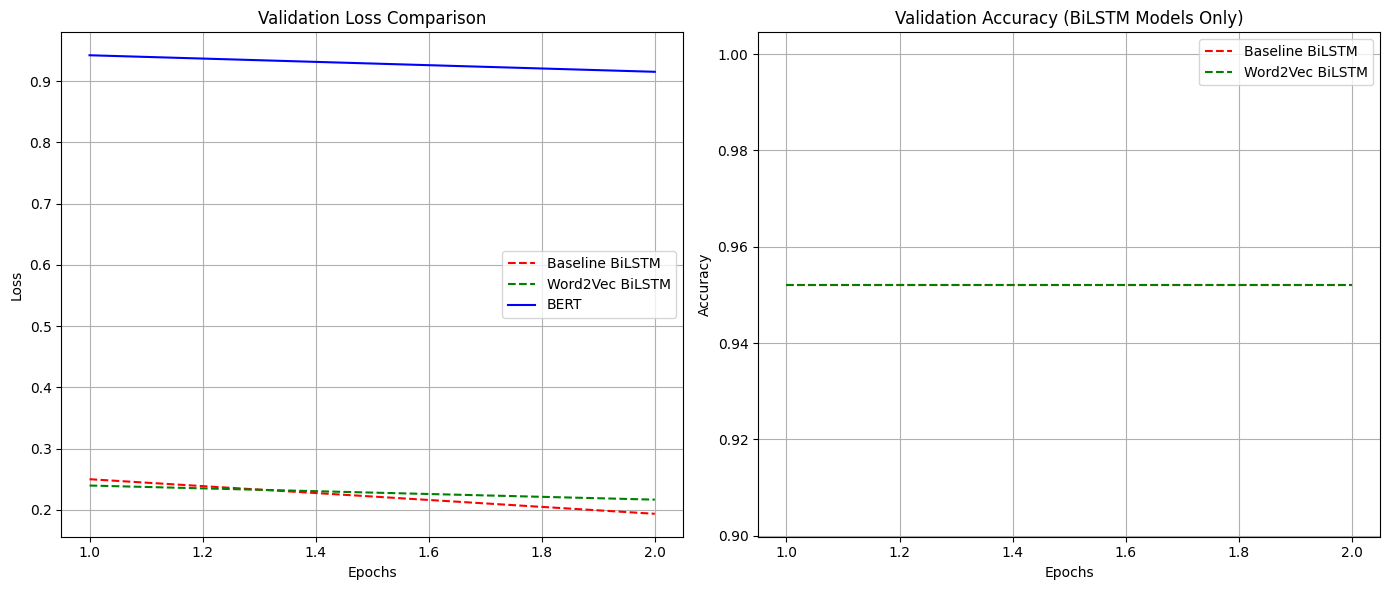

In [32]:
def plot_loss_accuracy_all(baseline_hist, w2v_hist, bert_hist):
    epochs_bi = range(1, len(baseline_hist.history['loss']) + 1)
    epochs_bert = range(1, len(bert_hist.history['loss']) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Loss plot
    axs[0].plot(epochs_bi, baseline_hist.history['val_loss'], 'r--', label='Baseline BiLSTM')
    axs[0].plot(epochs_bi, w2v_hist.history['val_loss'], 'g--', label='Word2Vec BiLSTM')
    axs[0].plot(epochs_bert, bert_hist.history['val_loss'], 'b-', label='BERT')
    axs[0].set_title("Validation Loss Comparison")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    # Accuracy plot (BERT doesn't track accuracy by default)
    axs[1].plot(epochs_bi, baseline_hist.history['val_accuracy'], 'r--', label='Baseline BiLSTM')
    axs[1].plot(epochs_bi, w2v_hist.history['val_accuracy'], 'g--', label='Word2Vec BiLSTM')
    axs[1].set_title("Validation Accuracy (BiLSTM Models Only)")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Call the function
plot_loss_accuracy_all(baseline_history, w2v_history, bert_history)
